# Sentiment / Emotion Classification

This notebook implements the sentiment classification module of the
RAG-based e-commerce customer support chatbot.

The `dair-ai/emotion` dataset contains six emotion classes:
sadness, joy, love, anger, fear, and surprise.

For chatbot routing, they are mapped into three sentiment categories:

- Negative: sadness, anger, fear
- Neutral: surprise
- Positive: joy, love

A Bidirectional LSTM (BiLSTM) is trained using class-weighted
cross-entropy loss to handle the strong class imbalance.
Macro-F1 is used for model selection because it gives equal importance
to all three classes.

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
from collections import Counter
from pathlib import Path
import json
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [23]:
print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.14.0+cpu
Device: cpu


In [24]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [25]:
dataset = load_dataset("dair-ai/emotion", "split")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [26]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [27]:
emotion_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
val_df["emotion"] = val_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df[["text", "emotion"]].head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [28]:
print(train_df["emotion"].value_counts())

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [29]:
sentiment_mapping = {
    "sadness": "negative",
    "anger": "negative",
    "fear": "negative",

    "joy": "positive",
    "love": "positive",

    "surprise": "neutral"
}

train_df["sentiment"] = train_df["emotion"].map(sentiment_mapping)
val_df["sentiment"] = val_df["emotion"].map(sentiment_mapping)
test_df["sentiment"] = test_df["emotion"].map(sentiment_mapping)

print(train_df["sentiment"].value_counts())

sentiment
negative    8762
positive    6666
neutral      572
Name: count, dtype: int64


In [30]:
sentiment_to_id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id_to_sentiment = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

train_df["sentiment_id"] = train_df["sentiment"].map(sentiment_to_id)
val_df["sentiment_id"] = val_df["sentiment"].map(sentiment_to_id)
test_df["sentiment_id"] = test_df["sentiment"].map(sentiment_to_id)

train_df.head()

,text,label,emotion,sentiment,sentiment_id
0,i didnt feel humiliated,0,sadness,negative,0
1,i can go from feeling so hopeless to so damned...,0,sadness,negative,0
2,im grabbing a minute to post i feel greedy wrong,3,anger,negative,0
3,i am ever feeling nostalgic about the fireplac...,2,love,positive,2
4,i am feeling grouchy,3,anger,negative,0


In [31]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text", "sentiment"]].head()

,text,clean_text,sentiment
0,i didnt feel humiliated,i didnt feel humiliated,negative
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,negative
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,negative
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,positive
4,i am feeling grouchy,i am feeling grouchy,negative


In [32]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

In [33]:
tokenize("I'm really angry about my order!")

['i', 'm', 'really', 'angry', 'about', 'my', 'order']

In [34]:
word_counts = Counter()

for text in train_df["clean_text"]:
    word_counts.update(tokenize(text))

min_freq = 2

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in word_counts.items():
    if count >= min_freq:
        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 7401


In [35]:
MAX_LENGTH = 64

def encode_text(text):
    tokens = tokenize(text)

    ids = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    ids = ids[:MAX_LENGTH]

    if len(ids) < MAX_LENGTH:
        ids += [vocab["<PAD>"]] * (MAX_LENGTH - len(ids))

    return ids

In [36]:
class SentimentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["clean_text"].tolist()
        self.labels = dataframe["sentiment_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        input_ids = torch.tensor(
            encode_text(self.texts[index]),
            dtype=torch.long
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return input_ids, label

In [37]:
train_dataset = SentimentDataset(train_df)
val_dataset = SentimentDataset(val_df)
test_dataset = SentimentDataset(test_df)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

print("Training batches:", len(train_loader))

Training batches: 250


In [38]:
class BiLSTMSentimentClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_classes=3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        _, (hidden, _) = self.lstm(embedded)

        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]

        hidden_combined = torch.cat(
            (hidden_forward, hidden_backward),
            dim=1
        )

        output = self.dropout(hidden_combined)

        return self.fc(output)

In [39]:
model = BiLSTMSentimentClassifier(
    vocab_size=len(vocab)
).to(device)

class_counts = (
    train_df["sentiment_id"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = len(train_df) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

Class weights: tensor([0.6087, 9.3240, 0.8001])
BiLSTMSentimentClassifier(
  (embedding): Embedding(7401, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


In [41]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for input_ids, labels in loader:
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [42]:
def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            outputs = model(input_ids)

            loss = criterion(outputs, labels)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total_loss += loss.item()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    avg_loss = total_loss / len(loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        avg_loss,
        accuracy,
        macro_f1,
        all_labels,
        all_predictions
    )

In [43]:
EPOCHS = 8
PATIENCE = 2

best_val_f1 = 0
patience_counter = 0

train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []

best_model_state = None

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_f1,
        _,
        _
    ) = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

        patience_counter = 0

    else:
        patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

Epoch 1/8 | Train Loss: 0.9776 | Val Loss: 0.6464 | Val Accuracy: 0.6585 | Val Macro-F1: 0.6517
Epoch 2/8 | Train Loss: 0.4989 | Val Loss: 0.4061 | Val Accuracy: 0.8080 | Val Macro-F1: 0.7492
Epoch 3/8 | Train Loss: 0.4812 | Val Loss: 0.6300 | Val Accuracy: 0.6485 | Val Macro-F1: 0.5636
Epoch 4/8 | Train Loss: 0.4143 | Val Loss: 0.2544 | Val Accuracy: 0.8960 | Val Macro-F1: 0.8249
Epoch 5/8 | Train Loss: 0.1684 | Val Loss: 0.1915 | Val Accuracy: 0.9375 | Val Macro-F1: 0.8878
Epoch 6/8 | Train Loss: 0.1185 | Val Loss: 0.1907 | Val Accuracy: 0.9405 | Val Macro-F1: 0.8914
Epoch 7/8 | Train Loss: 0.0976 | Val Loss: 0.1912 | Val Accuracy: 0.9410 | Val Macro-F1: 0.8943
Epoch 8/8 | Train Loss: 0.0856 | Val Loss: 0.1705 | Val Accuracy: 0.9500 | Val Macro-F1: 0.9021


In [44]:
model.load_state_dict(best_model_state)

model = model.to(device)

print(
    "Best Validation Macro-F1:",
    round(best_val_f1, 4)
)

Best Validation Macro-F1: 0.9021


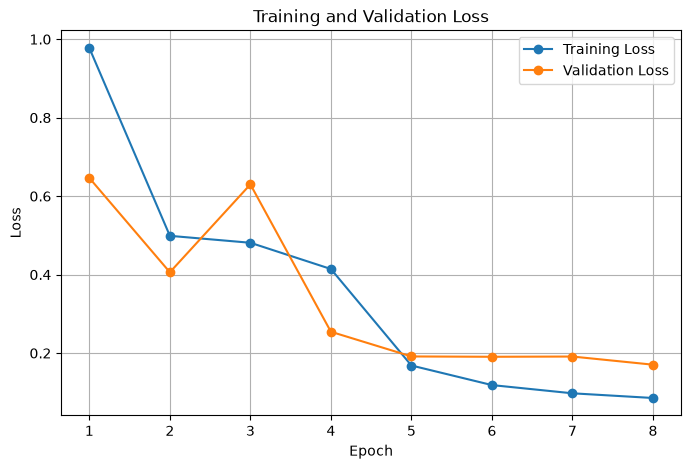

In [45]:
epochs_ran = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

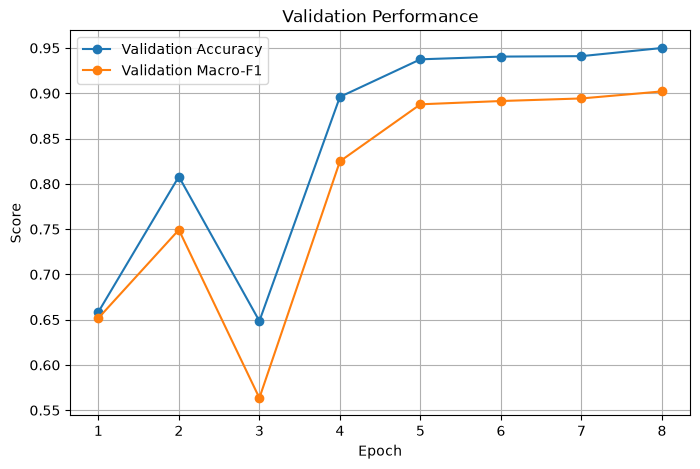

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    epochs_ran,
    val_f1_scores,
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")
plt.legend()
plt.grid()

plt.show()

In [47]:
(
    test_loss,
    test_accuracy,
    test_macro_f1,
    test_labels,
    test_predictions
) = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

print(
    "Test Macro-F1:",
    round(test_macro_f1, 4)
)

Test Loss: 0.206
Test Accuracy: 0.9385
Test Macro-F1: 0.8653


In [48]:
target_names = [
    "negative",
    "neutral",
    "positive"
]

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=target_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    negative     0.9647    0.9370    0.9507      1080
     neutral     0.5536    0.9394    0.6966        66
    positive     0.9571    0.9403    0.9486       854

    accuracy                         0.9385      2000
   macro avg     0.8251    0.9389    0.8653      2000
weighted avg     0.9479    0.9385    0.9414      2000



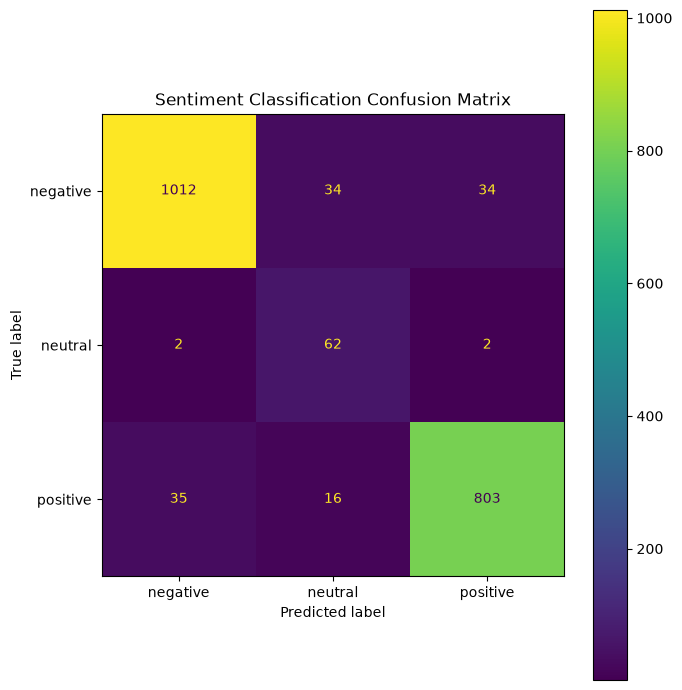

In [49]:
fig, ax = plt.subplots(
    figsize=(7, 7)
)

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=target_names,
    ax=ax
)

plt.title(
    "Sentiment Classification Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [50]:
def predict_sentiment(text):
    model.eval()

    cleaned = clean_text(text)

    encoded = encode_text(cleaned)

    input_ids = torch.tensor(
        [encoded],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():
        output = model(input_ids)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_id = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_id
        ].item()

    return (
        id_to_sentiment[predicted_id],
        confidence
    )

In [56]:
support_messages = [
    "I am furious, my package has still not arrived!",
    "Where can I check the status of my order?",
    "Thank you so much, everything arrived perfectly.",
    "This is ridiculous, I want my money back now.",
    "Can you tell me when my order will arrive?",
    "I really appreciate your help."
]

for message in support_messages:

    sentiment, confidence = predict_sentiment(
        message
    )

    print(
        f"Message: {message}"
    )

    print(
        f"Prediction: {sentiment} "
        f"({confidence:.2%})"
    )

    print("-" * 70)

Message: I am furious, my package has still not arrived!
Prediction: negative (99.63%)
----------------------------------------------------------------------
Message: Where can I check the status of my order?
Prediction: negative (66.48%)
----------------------------------------------------------------------
Message: Thank you so much, everything arrived perfectly.
Prediction: negative (58.02%)
----------------------------------------------------------------------
Message: This is ridiculous, I want my money back now.
Prediction: negative (83.23%)
----------------------------------------------------------------------
Message: Can you tell me when my order will arrive?
Prediction: negative (84.16%)
----------------------------------------------------------------------
Message: I really appreciate your help.
Prediction: positive (51.17%)
----------------------------------------------------------------------


In [57]:
current_path = Path.cwd()

if current_path.name == "Jupyter notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

sentiment_dir = (
    project_root
    / "models"
    / "sentiment_model"
)

sentiment_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Sentiment model directory:",
    sentiment_dir
)

Sentiment model directory: e:\iti\ass10\models\sentiment_model


In [58]:
torch.save(
    model.state_dict(),
    sentiment_dir / "sentiment_model.pt"
)

In [59]:
with open(
    sentiment_dir / "vocab.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        vocab,
        file,
        ensure_ascii=False,
        indent=2
    )

In [61]:
sentiment_config = {
    "vocab_size": len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "num_classes": 3,
    "max_length": MAX_LENGTH,
    "sentiment_to_id": sentiment_to_id,
    "id_to_sentiment": {
        str(key): value
        for key, value
        in id_to_sentiment.items()
    }
}

with open(
    sentiment_dir / "config.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        sentiment_config,
        file,
        indent=2
    )

print("Sentiment model saved successfully.")

Sentiment model saved successfully.


In [62]:
with open(
    sentiment_dir / "vocab.json",
    "r",
    encoding="utf-8"
) as file:

    loaded_vocab = json.load(file)


with open(
    sentiment_dir / "config.json",
    "r",
    encoding="utf-8"
) as file:

    loaded_config = json.load(file)


loaded_model = BiLSTMSentimentClassifier(
    vocab_size=loaded_config["vocab_size"],
    embedding_dim=loaded_config["embedding_dim"],
    hidden_dim=loaded_config["hidden_dim"],
    num_classes=loaded_config["num_classes"]
)

loaded_model.load_state_dict(
    torch.load(
        sentiment_dir / "sentiment_model.pt",
        map_location=device
    )
)

loaded_model = loaded_model.to(device)

loaded_model.eval()

print("Saved sentiment model loaded successfully.")

Saved sentiment model loaded successfully.


In [63]:
original_model = model

model = loaded_model
vocab_backup = vocab
vocab = loaded_vocab

sentiment, confidence = predict_sentiment(
    "I am very unhappy with my order."
)

print("Sentiment:", sentiment)
print(
    "Confidence:",
    round(confidence, 4)
)

model = original_model
vocab = vocab_backup

Sentiment: negative
Confidence: 0.9941


## Conclusion

The sentiment classification module was implemented using a Bidirectional
LSTM (BiLSTM).

The original six emotion classes were mapped into three customer-support
routing categories: negative, neutral, and positive.

Because the resulting classes were highly imbalanced, class-weighted
cross-entropy loss was used during training. Validation Macro-F1 was used
for model selection instead of relying only on accuracy.

The best model achieved a validation Macro-F1 of 0.9021. On the held-out
test set, it achieved 93.85% accuracy and a Macro-F1 of 0.8653.

The model performed strongly on negative and positive examples. Neutral
classification was more difficult because the original dataset contains
only a small number of surprise examples and does not contain a true
neutral class.

Testing with e-commerce customer-support messages also demonstrated domain
shift between the Twitter-based emotion dataset and real customer-support
language. Therefore, in the final chatbot, sentiment is mainly used to
adjust response tone and empathy, while complaint escalation also considers
the intent-classification result.

The trained model, vocabulary, and configuration were saved successfully
for integration with the final chatbot pipeline.